In [18]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

### Exploring files

In [3]:
datapath = Path.cwd()/'data/movielens'

In [4]:
for file in datapath.iterdir():
    print(file.name)

README.txt
ratings.csv
links.csv
movies.csv
genome-scores.csv
genome-tags.csv
tags.csv


### EXPLORE RATINGS DATA - 32M RATING FROM 1995 TO 2023

In [6]:
rating_df = pd.read_csv(datapath/'ratings.csv')

In [ ]:
rating_df['timeStamp']  = pd.to_datetime(rating_df["timeStamp"], unit='s')
rating_df.sort_values(by='timeStamp', inplace=True)

In [9]:
print(rating_df.columns)
print(rating_df.shape)

Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='object')
(33832162, 4)


In [11]:
rating_df.sort_values(by='timestamp', inplace=True)
rating_df['timestamp'] = pd.to_datetime(rating_df["timestamp"], unit='s')
rating_df.head(5)

,userId,movieId,rating,timestamp
15254009,149954,1176,4.0,1995-01-09 11:46:44
9617162,94532,1079,3.0,1995-01-09 11:46:49
9617113,94532,21,3.0,1995-01-09 11:46:49
9617119,94532,47,5.0,1995-01-09 11:46:49
5169054,50020,57,4.0,1996-01-29 00:00:00


In [12]:
rating_df.tail(5)

,userId,movieId,rating,timestamp
22026732,214831,281864,1.5,2023-07-20 08:24:00
29836322,291554,5282,3.5,2023-07-20 08:29:19
29836181,291554,1201,4.5,2023-07-20 08:41:31
29836625,291554,215173,4.5,2023-07-20 08:43:16
5623443,54638,288265,4.0,2023-07-20 08:53:33


### WORKING WITH A SUBSET OF DATA - 2021 to 2023
* #### 28570 unique users and 60068 unique movies
* #### There are 4991 users who wrote lesser than 5 reviews
* #### There are 38197 movies which got lesser than 5 reviews

In [68]:
small_rating_df = rating_df[rating_df['timestamp'] > '01-01-2019']
small_rating_df.shape

(6027246, 4)

In [69]:
n_users = len(small_rating_df['userId'].unique())
n_items = len(small_rating_df['movieId'].unique())
print(f"{n_users} unique users and {n_items} unique movies")

52919 unique users and 74968 unique movies


Text(0, 0.5, 'Counts')

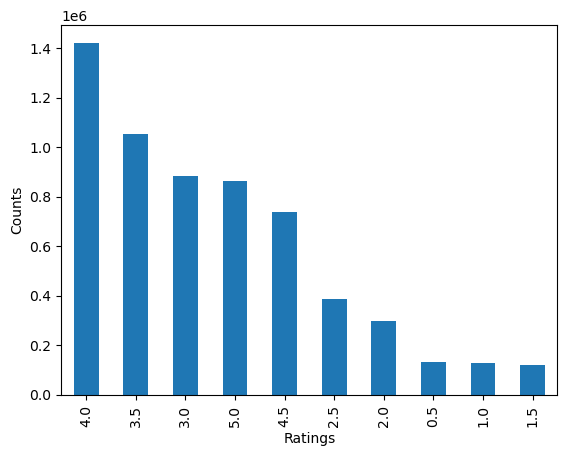

In [70]:
small_rating_df["rating"].value_counts().plot(kind='bar')
plt.xlabel("Ratings")
plt.ylabel("Counts")

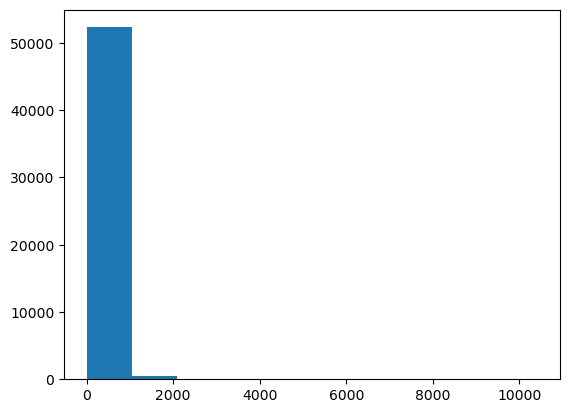

In [71]:
plt.hist(small_rating_df.groupby(by='userId')['rating'].count().values) 

plt.show()

In [72]:
m  = sum(small_rating_df.groupby(by='userId')['rating'].count() < 5)
print(f"There are {m} users who wrote lesser than 5 reviews")

There are 8116 users who wrote lesser than 5 reviews


In [73]:
m  = sum(small_rating_df.groupby(by='movieId')['rating'].count() < 5)
print(f"There are {m} movies which got lesser than 5 reviews")

There are 42756 movies which got lesser than 5 reviews


### PREPARE TRAIN AND TEST DATASET

In [116]:
n = small_rating_df.shape[0]
n_train = int(n*0.7)

train_df = small_rating_df.iloc[:n_train]
test_df = small_rating_df.iloc[n_train: ]

In [117]:
print(train_df.shape)
print(test_df.shape)

(4219072, 4)
(1808174, 4)


In [118]:
unique_movies = set(train_df['movieId'].unique())
unique_users = set(train_df['userId'].unique())

In [119]:
test_df = test_df[test_df['movieId'].isin(unique_movies)]
test_df = test_df[test_df['userId'].isin(unique_users)]

In [129]:
train_df.columns = ['userId', 'productId', 'rating', 'timestamp']
test_df.columns = ['userId', 'productId', 'rating', 'timestamp']

In [130]:
train_df.to_csv("data/movielens/train.csv")
test_df.to_csv("data/movielens/test.csv")

In [131]:
from MF_ALS.architecture import Encoder

In [132]:
enc = Encoder()

In [133]:
enc.encode(train_df)

In [135]:
enc.id_user

{0: 164814,
 1: 287008,
 2: 203016,
 3: 37118,
 4: 75812,
 5: 81316,
 6: 209361,
 7: 188550,
 8: 134787,
 9: 168149,
 10: 4127,
 11: 138930,
 12: 133621,
 13: 122776,
 14: 19822,
 15: 215106,
 16: 67127,
 17: 319291,
 18: 8558,
 19: 295723,
 20: 160897,
 21: 236261,
 22: 195894,
 23: 304845,
 24: 257260,
 25: 134034,
 26: 297111,
 27: 6259,
 28: 144421,
 29: 330942,
 30: 267547,
 31: 107584,
 32: 299380,
 33: 270735,
 34: 184604,
 35: 318422,
 36: 47550,
 37: 275494,
 38: 111877,
 39: 264808,
 40: 194364,
 41: 22537,
 42: 308203,
 43: 289075,
 44: 11969,
 45: 31994,
 46: 234355,
 47: 238278,
 48: 98947,
 49: 230713,
 50: 69060,
 51: 212511,
 52: 115509,
 53: 306954,
 54: 9619,
 55: 175970,
 56: 230778,
 57: 269475,
 58: 253363,
 59: 208870,
 60: 284655,
 61: 177903,
 62: 71511,
 63: 104198,
 64: 288497,
 65: 71076,
 66: 25497,
 67: 30319,
 68: 48178,
 69: 108773,
 70: 98780,
 71: 59008,
 72: 251655,
 73: 205636,
 74: 302082,
 75: 265236,
 76: 97062,
 77: 220599,
 78: 116027,
 79: 9808,